# 05 — Model Evaluation
**Best model**: XGBoost (CV AUC: 0.9194)  
**Input**: `models/` + `models/train_test_split.pkl`  
**Output**: `reports/model_comparison.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score
)

sns.set_theme(style='whitegrid')
FIGURES_DIR = '../reports/figures/'

# Load split
X_train, X_test, y_train, y_test = joblib.load('../models/train_test_split.pkl')

# Safety — ensure numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test  = X_test.apply(pd.to_numeric,  errors='coerce').fillna(0)

# Load models
models = {
    'XGBoost'             : joblib.load('../models/xgboost.pkl'),
    'LightGBM'            : joblib.load('../models/lightgbm.pkl'),
    'Logistic Regression' : joblib.load('../models/logistic_regression.pkl'),
    'Random Forest'       : joblib.load('../models/random_forest.pkl'),
}
best_model = models['XGBoost']
print('✅ All models loaded')
print(f'Test set: {X_test.shape[0]} samples | Churn rate: {y_test.mean():.3f}')

✅ All models loaded
Test set: 1405 samples | Churn rate: 0.265


## 2. Confusion Matrix — XGBoost

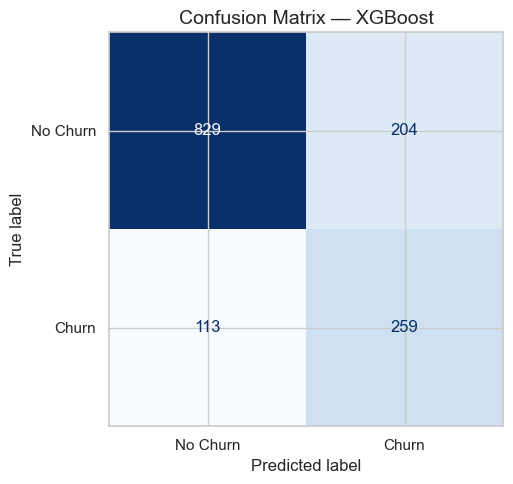

True  Negatives : 829
False Positives : 204
False Negatives : 113  ← most costly!
True  Positives : 259


In [2]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'confusion_matrix_xgboost.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives : {tn}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}  ← most costly!')
print(f'True  Positives : {tp}')

## 3. Classification Report

In [3]:
print('Classification Report — XGBoost')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')

Classification Report — XGBoost
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1033
       Churn       0.56      0.70      0.62       372

    accuracy                           0.77      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.77      0.78      1405

ROC-AUC  : 0.8461
F1 Score : 0.6204
Precision: 0.5594
Recall   : 0.6962


## 4. ROC Curves — All Models

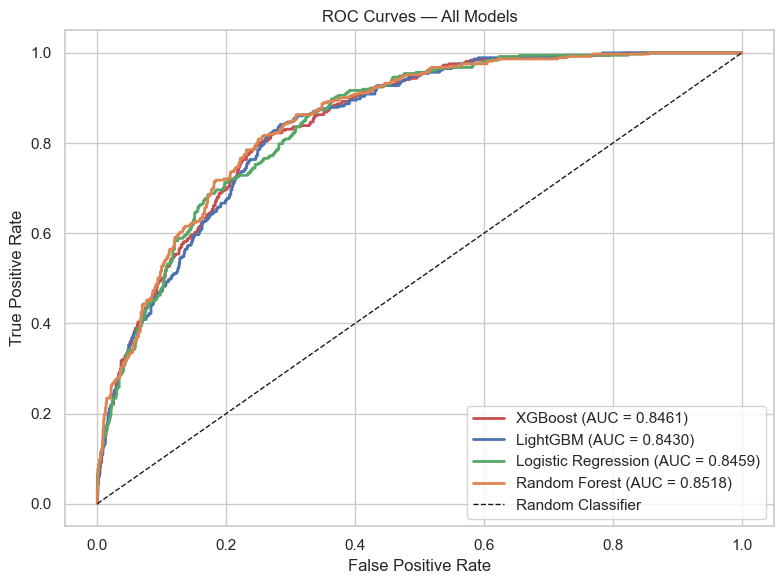

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52', '#4C72B0', '#55A868', '#DD8452']
for (name, model), color in zip(models.items(), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'roc_curves_all_models.png')
plt.show()

## 5. Precision-Recall Curve

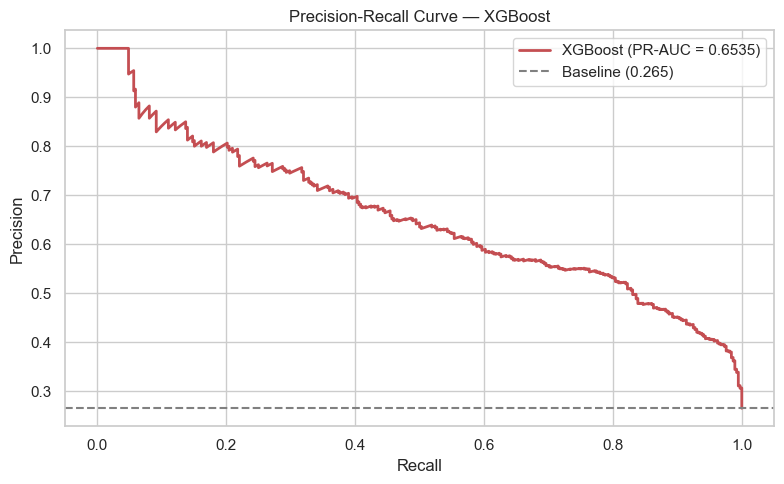

In [5]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color='#C44E52', lw=2, label=f'XGBoost (PR-AUC = {pr_auc:.4f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'precision_recall_curve.png')
plt.show()

## 6. Threshold Tuning

,Threshold,Precision,Recall,F1
0,0.20,0.4517,0.8925,0.5998
1,0.25,0.4762,0.8602,0.6130
2,0.30,0.5016,0.8306,0.6255
3,0.35,0.5217,0.8091,0.6344
4,0.40,0.5400,0.7796,0.6381
5,0.45,0.5500,0.7392,0.6307
6,0.50,0.5594,0.6962,0.6204
7,0.55,0.5681,0.6505,0.6065
8,0.60,0.5864,0.6022,0.5942
9,0.65,0.6134,0.5672,0.5894


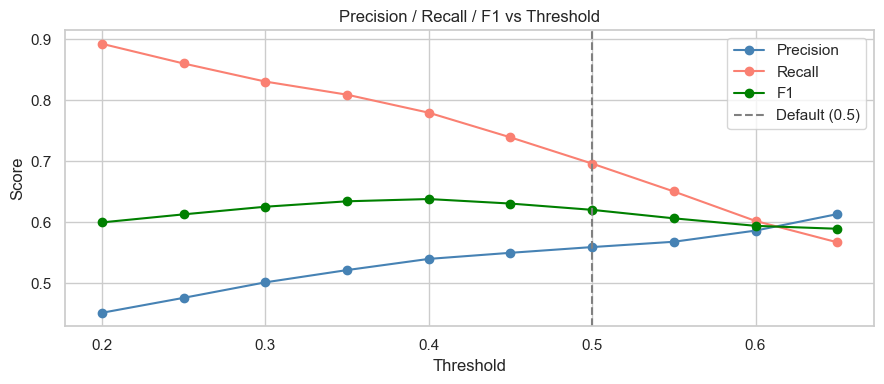


✅ Best threshold by F1: 0.4


In [6]:
threshold_results = []
for t in np.arange(0.2, 0.7, 0.05):
    y_pred_t = (y_prob >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'Recall'   : round(recall_score(y_test, y_pred_t), 4),
        'F1'       : round(f1_score(y_test, y_pred_t), 4),
    })
thresh_df = pd.DataFrame(threshold_results)
display(thresh_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], marker='o', label='Precision', color='steelblue')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    marker='o', label='Recall',    color='salmon')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        marker='o', label='F1',        color='green')
ax.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'threshold_tuning.png')
plt.show()

best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f'\n✅ Best threshold by F1: {best_thresh}')

## 7. Feature Importance — XGBoost

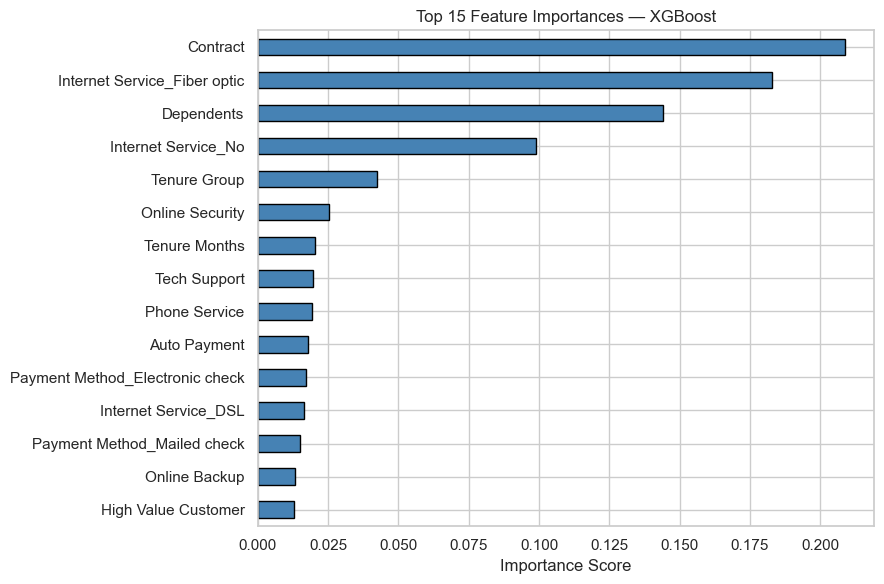

In [7]:
importance = pd.Series(
    best_model.feature_importances_, index=X_test.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
importance.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 15 Feature Importances — XGBoost')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'feature_importance_xgboost.png')
plt.show()

## 8. Full Model Comparison Table

In [9]:
os.makedirs('../reports', exist_ok=True)
comparison = []
for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    comparison.append({
        'Model'    : name,
        'ROC-AUC'  : round(roc_auc_score(y_test, prob), 4),
        'F1'       : round(f1_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
    })
comp_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comp_df.index += 1
display(comp_df)
comp_df.to_csv('../reports/model_comparison.csv', index=False)
print('\n✅ Saved: reports/model_comparison.csv')


,Model,ROC-AUC,F1,Precision,Recall
1,Random Forest,0.8518,0.6365,0.5603,0.7366
2,XGBoost,0.8461,0.6204,0.5594,0.6962
3,Logistic Regression,0.8459,0.6256,0.5680,0.6962
4,LightGBM,0.8430,0.6027,0.5499,0.6667



✅ Saved: reports/model_comparison.csv
